# 🚗 Egyptian License Plate Detection — YOLOv8

## 1️⃣ Install & Import Libraries

In [10]:
!pip install ultralytics -q --no-deps

In [11]:
!pip install opencv-python-headless PyYAML scipy matplotlib pandas psutil py-cpuinfo -q

In [12]:
import torch
print(torch.cuda.is_available()) 
print(torch.__version__)

True
2.10.0+cu128


In [13]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

## 2️⃣ Configuration & Paths

### Dataset Paths (Kaggle)

In [14]:
BASE_PATH    = '/kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset'
IMG_FOLDER   = os.path.join(BASE_PATH, 'Vehicles')
LABEL_FOLDER = os.path.join(BASE_PATH, 'Vehicles Labeling')

### YOLO Dataset Directory (working dir)

In [15]:
YOLO_DIR = Path('/kaggle/working/yolo_dataset')
for split in ['train', 'val', 'test']:
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

### Hyperparameters

In [16]:
IMG_SIZE   = 640   # YOLO standard input size
BATCH_SIZE = 16
EPOCHS     = 50
MODEL_SIZE = 'yolov8n.pt'  # nano | yolov8s.pt | yolov8m.pt
CLASS_NAMES = ['license_plate']

In [17]:
print(f'📂 Images  : {IMG_FOLDER}')
print(f'📂 Labels  : {LABEL_FOLDER}')
print(f'📁 YOLO Dir: {YOLO_DIR}')

📂 Images  : /kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset/Vehicles
📂 Labels  : /kaggle/input/datasets/mahmoudeldebase/egyptian-cars-plates/EALPR Vechicles dataset/Vehicles Labeling
📁 YOLO Dir: /kaggle/working/yolo_dataset


## 3️⃣ Prepare YOLO Dataset

> The dataset already uses **YOLO format** labels (`.txt` files with `class cx cy w h` — all normalized).  
> We just need to **split** and **copy** into the YOLO directory structure.

In [18]:
def get_pairs(img_folder, label_folder):
    """Return matched (image_path, label_path) pairs."""
    pairs = []
    for f in sorted(os.listdir(img_folder)):
        if f.endswith('.jpg'):
            img_p   = os.path.join(img_folder, f)
            label_p = os.path.join(label_folder, f.replace('.jpg', '.txt'))
            if os.path.exists(label_p):
                pairs.append((img_p, label_p))
    return pairs

pairs = get_pairs(IMG_FOLDER, LABEL_FOLDER)
print(f'📊 Total matched pairs: {len(pairs)}')

# ── Train / Val / Test split ─────────────────────────────────────────────
train_pairs, temp_pairs = train_test_split(pairs, test_size=0.2, random_state=42)
val_pairs,   test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42)

print(f'  Train : {len(train_pairs)}')
print(f'  Val   : {len(val_pairs)}')
print(f'  Test  : {len(test_pairs)}')

📊 Total matched pairs: 2031
  Train : 1624
  Val   : 203
  Test  : 204


In [19]:
def copy_pairs(pairs, split):
    """Copy images and labels into the YOLO directory structure."""
    for img_p, label_p in pairs:
        fname = os.path.basename(img_p)
        shutil.copy(img_p,   YOLO_DIR / 'images' / split / fname)
        shutil.copy(label_p, YOLO_DIR / 'labels' / split / fname.replace('.jpg', '.txt'))

copy_pairs(train_pairs, 'train')
copy_pairs(val_pairs,   'val')
copy_pairs(test_pairs,  'test')
print('✅ Dataset copied to YOLO structure!')

✅ Dataset copied to YOLO structure!


In [20]:
data_yaml = {
    'path'  : str(YOLO_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : len(CLASS_NAMES),
    'names' : CLASS_NAMES
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, allow_unicode=True)

print('📄 data.yaml:')
print(open(yaml_path).read())

📄 data.yaml:
names:
- license_plate
nc: 1
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val



## 4️⃣ Visualize Sample Annotations

> Quick sanity check — make sure labels are aligned with images.

/tmp/ipykernel_97/232966443.py:31: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


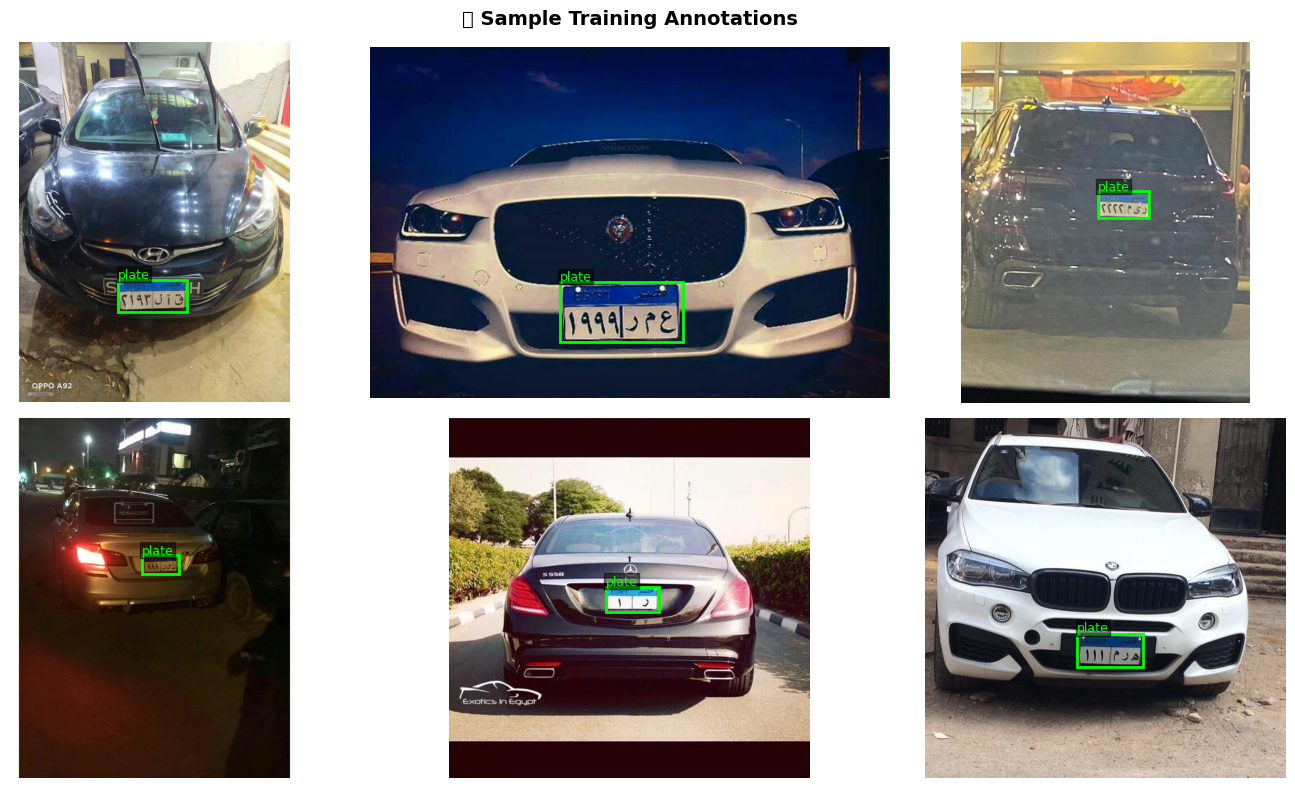

In [21]:
def show_annotated_sample(img_path, label_path, ax):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax.imshow(img)
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            _, cx, cy, bw, bh = map(float, parts[:5])
            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, 'plate', color='lime', fontsize=9,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
    ax.axis('off')

samples = random.sample(train_pairs, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('🔍 Sample Training Annotations', fontsize=14, fontweight='bold')

for ax, (img_p, lbl_p) in zip(axes.flat, samples):
    show_annotated_sample(img_p, lbl_p, ax)

plt.tight_layout()
plt.show()

## 5️⃣ Train YOLOv8

| Parameter | Value | Notes |
|-----------|-------|-------|
| Model | `yolov8n` | Nano — fastest; swap to `yolov8s` for better accuracy |
| imgsz | 640 | YOLO native size |
| epochs | 50 | With early stopping |
| batch | 16 | Adjust if GPU OOM |
| patience | 10 | Early stopping patience |

In [22]:
# Load pretrained YOLOv8 nano
model = YOLO(MODEL_SIZE)

# Train
results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    patience  = 10,          # early stopping
    device    = 0,            # GPU; use 'cpu' if no GPU
    project   = '/kaggle/working/runs',
    name      = 'plate_yolov8',
    exist_ok  = True,
    # ── Augmentation ────────────────────────────────────
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    degrees   = 5.0,
    translate = 0.1,
    scale     = 0.5,
    flipud    = 0.0,          # plates don't appear upside-down
    fliplr    = 0.5,
    mosaic    = 1.0,
    mixup     = 0.1,
)

print('✅ Training complete!')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

## 6️⃣ Evaluation

In [23]:
# ── Load best checkpoint ──────────────────────────────────────────────────
best_model_path = '/kaggle/working/runs/plate_yolov8/weights/best.pt'
best_model = YOLO(best_model_path)

# ── Validate on test split ────────────────────────────────────────────────
metrics = best_model.val(
    data    = str(yaml_path),
    split   = 'test',
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    device  = 0,
    project = '/kaggle/working/runs',
    name    = 'plate_yolov8_eval',
    exist_ok= True,
)

print('\n📊 Test Set Metrics:')
print(f'  mAP@50     : {metrics.box.map50:.4f}')
print(f'  mAP@50-95  : {metrics.box.map:.4f}')
print(f'  Precision  : {metrics.box.mp:.4f}')
print(f'  Recall     : {metrics.box.mr:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1509.5±655.1 MB/s, size: 76.4 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/test... 204 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 204/204 1.2Kit/s 0.2s<0.2s
val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.1it/s 3.1s0.1s
                   all        204        209          1      0.989      0.995       0.89
Speed: 2.4ms preprocess, 5.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/plate_yolov8_eval

📊 Test Set Metrics:
  mAP@50     : 0.9950
  mAP@50-95  : 0.8897
  Precision  : 1.0000
  Recall     : 0.9894


/tmp/ipykernel_97/2239306130.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


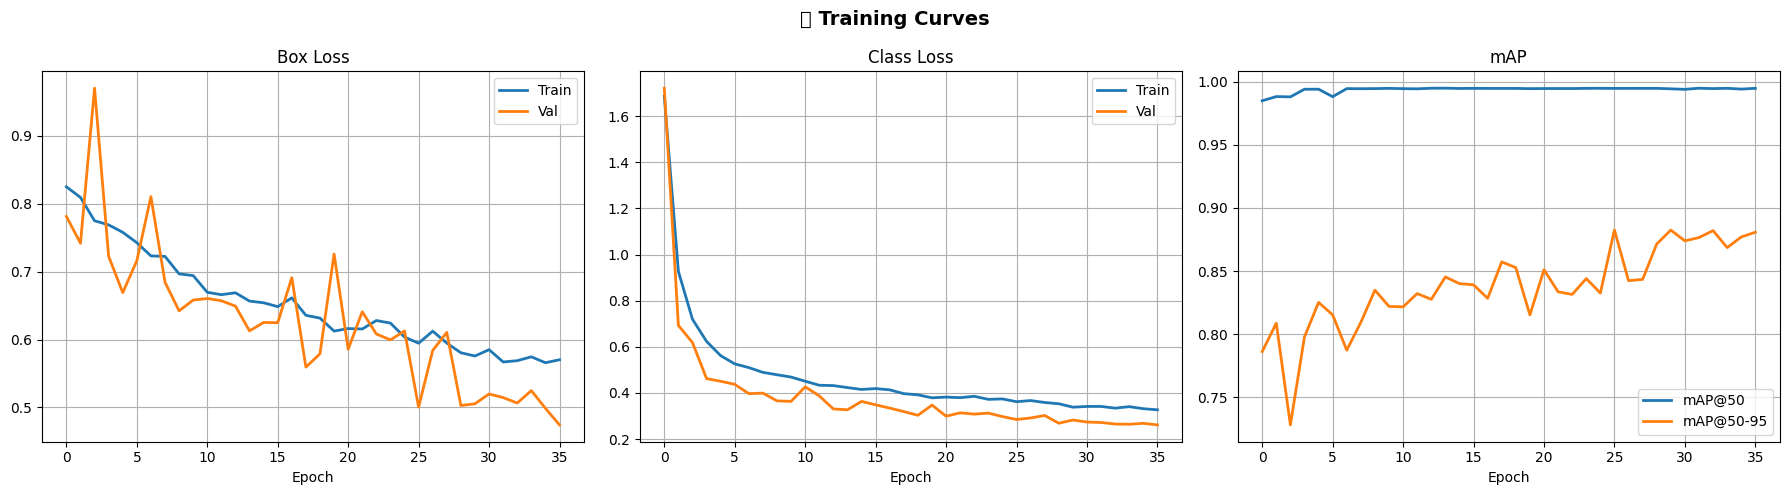

In [24]:
# ── Plot training curves from results.csv ────────────────────────────────
import pandas as pd

results_csv = '/kaggle/working/runs/plate_yolov8/results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()   # remove whitespace from column names

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 Training Curves', fontsize=14, fontweight='bold')

# Box Loss
axes[0].plot(df['train/box_loss'], label='Train', linewidth=2)
axes[0].plot(df['val/box_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

# Objectness Loss (cls loss in v8 = classification, dfl = distribution focal)
axes[1].plot(df['train/cls_loss'], label='Train', linewidth=2)
axes[1].plot(df['val/cls_loss'],   label='Val',   linewidth=2)
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

# mAP
axes[2].plot(df['metrics/mAP50(B)'],    label='mAP@50',    linewidth=2)
axes[2].plot(df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)
axes[2].set_title('mAP')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 7️⃣ Inference on Test Images

/tmp/ipykernel_97/768871374.py:40: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


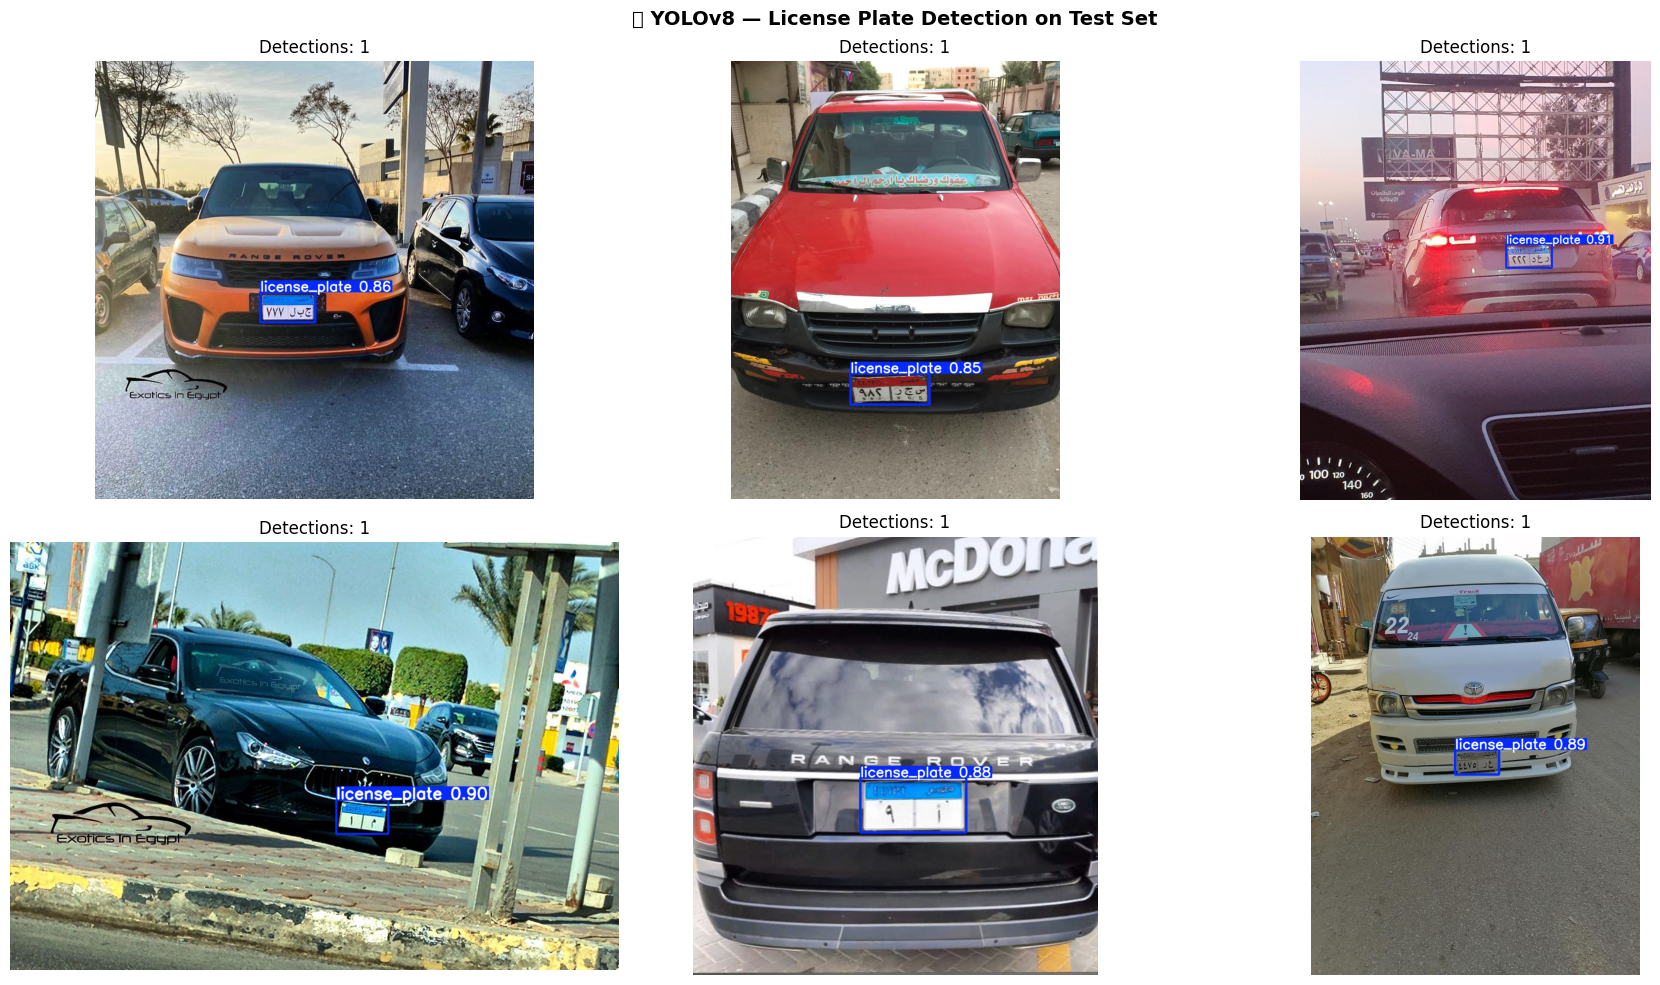

In [25]:
def predict_and_show(img_path, model, conf_threshold=0.25, ax=None):
    """
    Run YOLO inference and display result with bounding boxes.
    Returns the raw Results object.
    """
    results = model.predict(
        source = img_path,
        conf   = conf_threshold,
        imgsz  = IMG_SIZE,
        verbose= False
    )[0]

    annotated = results.plot()  # BGR numpy array with boxes drawn
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    if ax is None:
        plt.figure(figsize=(8, 6))
        plt.imshow(annotated)
        plt.axis('off')
        plt.title(f'Detections: {len(results.boxes)}')
        plt.show()
    else:
        ax.imshow(annotated)
        ax.axis('off')
        ax.set_title(f'Detections: {len(results.boxes)}')

    return results


# ── Run on 6 random test images ──────────────────────────────────────────
test_imgs = list((YOLO_DIR / 'images' / 'test').glob('*.jpg'))
samples   = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🚗 YOLOv8 — License Plate Detection on Test Set', fontsize=14, fontweight='bold')

for ax, img_p in zip(axes.flat, samples):
    predict_and_show(str(img_p), best_model, ax=ax)

plt.tight_layout()
plt.show()

## 8️⃣ IoU Analysis — How Accurate Are the Boxes?


📊 IoU Analysis on Test Set (204 images):
  Detections found : 204
  No detection     : 0
  Mean IoU         : 0.9088
  Median IoU       : 0.9226
  IoU >= 0.5       : 202/204 (99.0%)
  IoU >= 0.75      : 202/204 (99.0%)


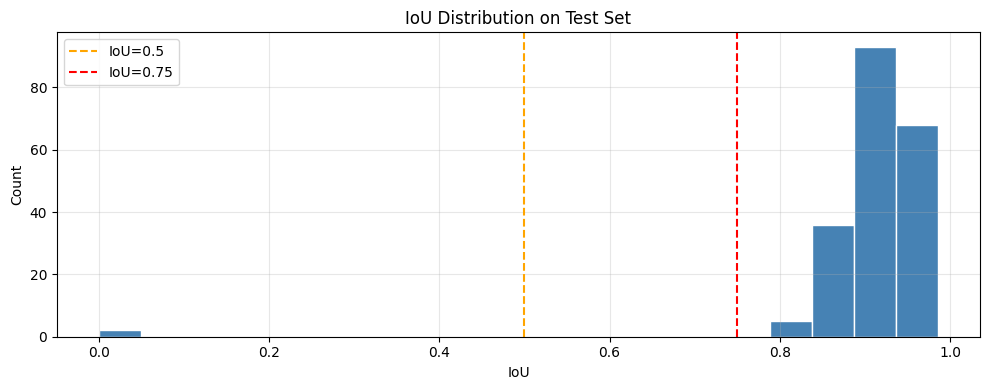

In [26]:
def compute_iou(box_pred, box_true):
    """
    box format: [x1, y1, x2, y2] (pixel coords)
    """
    xi1 = max(box_pred[0], box_true[0])
    yi1 = max(box_pred[1], box_true[1])
    xi2 = min(box_pred[2], box_true[2])
    yi2 = min(box_pred[3], box_true[3])

    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area_pred = (box_pred[2]-box_pred[0]) * (box_pred[3]-box_pred[1])
    area_true = (box_true[2]-box_true[0]) * (box_true[3]-box_true[1])
    union = area_pred + area_true - inter + 1e-6

    return inter / union


ious = []
no_det = 0

for img_p in test_imgs:
    label_p = YOLO_DIR / 'labels' / 'test' / img_p.with_suffix('.txt').name
    if not label_p.exists():
        continue

    img = cv2.imread(str(img_p))
    h, w = img.shape[:2]

    with open(label_p) as f:
        line = f.readline().strip().split()
    if len(line) < 5:
        continue
    _, cx, cy, bw, bh = map(float, line[:5])
    true_box = [
        (cx - bw/2)*w, (cy - bh/2)*h,
        (cx + bw/2)*w, (cy + bh/2)*h
    ]

    res = best_model.predict(str(img_p), conf=0.25, imgsz=IMG_SIZE, verbose=False)[0]

    if len(res.boxes) == 0:
        no_det += 1
        continue

    pred_box = res.boxes.xyxy[0].cpu().numpy()
    ious.append(compute_iou(pred_box, true_box))

print(f'\n📊 IoU Analysis on Test Set ({len(test_imgs)} images):')
print(f'  Detections found : {len(ious)}')
print(f'  No detection     : {no_det}')
if ious:
    print(f'  Mean IoU         : {np.mean(ious):.4f}')
    print(f'  Median IoU       : {np.median(ious):.4f}')
    print(f'  IoU >= 0.5       : {sum(i >= 0.5 for i in ious)}/{len(ious)} ({100*sum(i>=0.5 for i in ious)/len(ious):.1f}%)')
    print(f'  IoU >= 0.75      : {sum(i >= 0.75 for i in ious)}/{len(ious)} ({100*sum(i>=0.75 for i in ious)/len(ious):.1f}%)')

    plt.figure(figsize=(10, 4))
    plt.hist(ious, bins=20, color='steelblue', edgecolor='white')
    plt.axvline(0.5,  color='orange', linestyle='--', label='IoU=0.5')
    plt.axvline(0.75, color='red',    linestyle='--', label='IoU=0.75')
    plt.title('IoU Distribution on Test Set')
    plt.xlabel('IoU')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9️⃣ Export Model

> Export to ONNX for deployment, or keep `.pt` for Torch-based inference.

In [27]:
# Export to ONNX
best_model.export(format='onnx', imgsz=IMG_SIZE)
print('✅ ONNX model exported!')

# The .pt file is also useful — let's confirm its location
print(f'📦 PyTorch weights : {best_model_path}')

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/plate_yolov8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 274ms
Prepared 2 packages in 2.90s
Installed 2 packages in 22ms
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 3.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 5.1s, saved as '/kaggle/working/runs/plate_yolov8/weights/best.onnx' (11.7 MB)

Ex

---

## 🆚 CNN vs YOLO — Key Differences

| Aspect | CNN (Custom) | YOLOv8 |
|--------|-------------|--------|
| **Architecture** | Custom residual + grid head | CSPDarknet + FPN neck + detection head |
| **Grid** | Fixed 26×26 | Multi-scale (80×80, 40×40, 20×20) |
| **Anchor boxes** | None (direct regression) | Anchor-free (v8) |
| **Loss** | Custom detection loss | CIoU + BCE + DFL |
| **Transfer Learning** | From scratch | COCO pretrained ✅ |
| **Augmentation** | Basic | Mosaic, MixUp, HSV |
| **Metric** | MAE | mAP@50, mAP@50-95 |
| **Deployment** | TF SavedModel / Keras | ONNX / TorchScript / CoreML |

**Why YOLO wins on this task:**  
- Pretrained on COCO → learns general object features, not noise  
- Multi-scale detection → handles plates of all sizes  
- Industry-standard mAP metric → comparable to published benchmarks

## Thank You🎀🫶🏻💌💓 